In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rhythmic_segments import RhythmicSegments

import sys
sys.path.append('../')
from src.synthetic import *
from src.utils import savefig
from src.patdur import quantal_pattern_duration_plot
from src.cluster import clustered_pattern_duration_plot

# If true the data will be refreshed and written to disk
REFRESH = False

In [2]:
def flattish(N):
    template = np.zeros(2*N)
    for i in range(N):
        template[2*i] = i + 1 
        template[2*N - 2*i - 1] = i + 1
    return template[:-1]

In [3]:
np.random.seed(1)
template = flattish(6)
intervals = .2 * repeat_template(template, noise_amount=.2, size=1000)
rs = RhythmicSegments.from_intervals(intervals, length=2)

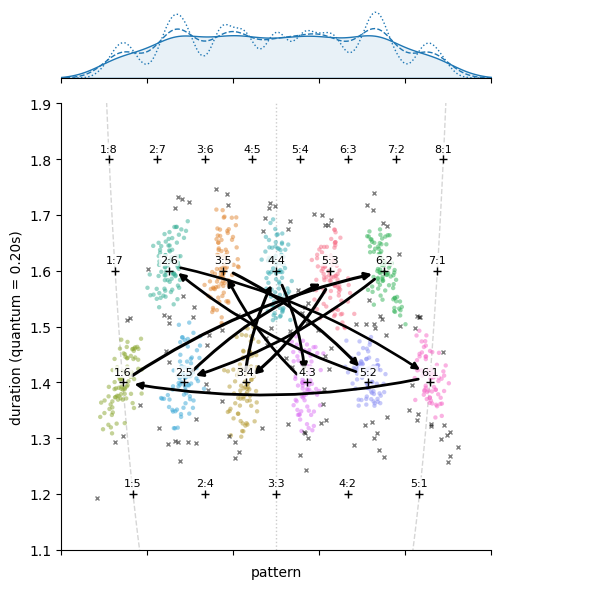

In [4]:
g = clustered_pattern_duration_plot(rs, ratio=5)
quantal_pattern_duration_plot(.2, ax=g.ax_joint)
g.ax_joint.set_ylim(5.5 * .2, 9.5*.2)
g.ax_joint.set_xlim(0, 1)

# Hide right marginal
g.ax_marg_y.cla()
g.ax_marg_y.axis('off')

# Replace top marginal
g.ax_marg_x.cla()
lines_kws= dict(color='C0', lw=1, ax=g.ax_marg_x)
sns.kdeplot(x=rs.patterns[:, 0], bw_adjust=1, label='bw 1', fill=True, alpha=.1, **lines_kws)
sns.kdeplot(x=rs.patterns[:, 0], bw_adjust=2/3, ls="--", label='bw 2/3', fill=False, **lines_kws)
sns.kdeplot(x=rs.patterns[:, 0], bw_adjust=1/3, ls=":", label='bw 1/3', fill=False,  **lines_kws)
g.ax_marg_x.set_yticks([])
g.ax_marg_x.set_xticklabels([])
g.ax_marg_x.set_ylabel('')

plt.tight_layout()
savefig('flat-ratio-plot', refresh=REFRESH)

([], [])

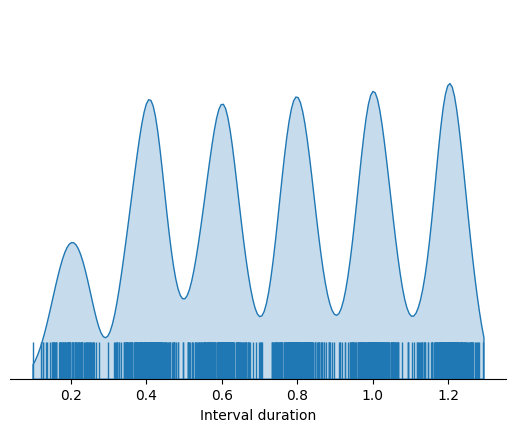

In [5]:
ax = plt.gca()
sns.kdeplot(intervals, fill=True, bw_adjust=1/3, ax=ax, cut=0)
sns.rugplot(intervals, ax=ax, height=.1)
sns.despine(left=True)
plt.ylabel('')
plt.xlabel('Interval duration')
plt.yticks([])